# LightGBM Model

In this notebook, we train LightGBM for phishing website detection.
We keep one hold-out test split and perform hyperparameter tuning with cross-validation on the training split only.


In [1]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from lightgbm import LGBMClassifier

import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load Clean Dataset
df = pd.read_csv("../../data/processed-phishing.csv")


In [3]:
# Separate features and target variable
X = df.drop("Result", axis=1)
y = df["Result"].replace({-1: 0, 1: 1})

print(X.shape)
print(y.shape)


(5849, 30)
(5849,)


In [4]:
# Train/Test Split (hold-out test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


## 1) Hyperparameter Tuning with CV (train only)

We tune LightGBM using GridSearchCV with 5-fold stratified CV.
The test split is kept untouched until final evaluation.


In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 5, 10],
}

grid = GridSearchCV(
    LGBMClassifier(objective="binary", random_state=42, verbosity=-1),
    param_grid=param_grid,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

lgbm = grid.best_estimator_
print("Best Params:", grid.best_params_)


Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 31}


In [6]:
# CV summary for selected model
cv_results = cross_validate(
    lgbm,
    X_train,
    y_train,
    cv=skf,
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1,
)

print("LightGBM CV (train-only)")
print(f"CV Accuracy: {cv_results['test_accuracy'].mean():.4f} +/- {cv_results['test_accuracy'].std():.4f}")
print(f"CV Accuracy Variance: {cv_results['test_accuracy'].var():.6f}")
print(f"CV Precision: {cv_results['test_precision'].mean():.4f}")
print(f"CV Recall: {cv_results['test_recall'].mean():.4f}")
print(f"CV F1 Score: {cv_results['test_f1'].mean():.4f}")


LightGBM CV (train-only)
CV Accuracy: 0.9511 +/- 0.0064
CV Accuracy Variance: 0.000041
CV Precision: 0.9450
CV Recall: 0.9545
CV F1 Score: 0.9497


## 2) Final Hold-out Test Evaluation

After tuning and CV on the training split, we fit the best model on full training data and evaluate once on test data.


LightGBM (Tuned with CV) Test Results:

Accuracy: 0.9564102564102565
Precision: 0.9557522123893806
Recall: 0.9540636042402827
F1 Score: 0.9549071618037135

Confusion Matrix:
[[579  25]
 [ 26 540]]


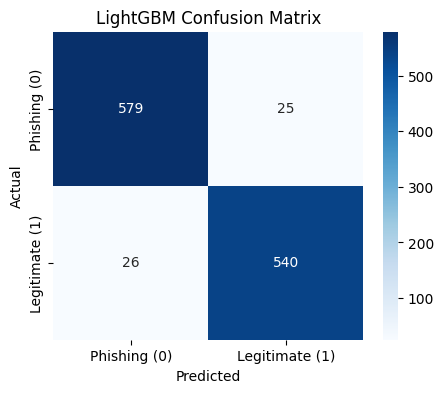

In [7]:
# Final fit + test evaluation
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)

print("LightGBM (Tuned with CV) Test Results:")
print()
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Phishing (0)", "Legitimate (1)"],
    yticklabels=["Phishing (0)", "Legitimate (1)"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Confusion Matrix")
plt.show()


In [8]:
# Overfitting check
y_train_pred = lgbm.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))


Train Accuracy: 0.9807651207522975
Test Accuracy: 0.9564102564102565


## 3) Feature Analysis

LightGBM provides built-in feature importance scores from split statistics.


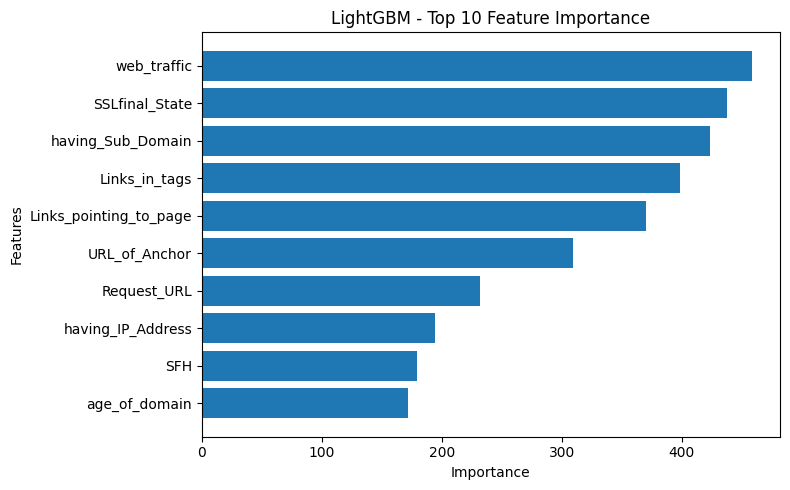

Top 10 Important Features:
                   Feature  Importance
25             web_traffic         459
7           SSLfinal_State         438
6        having_Sub_Domain         424
14           Links_in_tags         399
28  Links_pointing_to_page         370
13           URL_of_Anchor         309
12             Request_URL         232
0        having_IP_Address         194
15                     SFH         179
23           age_of_domain         172


In [9]:
# Feature importance
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm.feature_importances_,
}).sort_values(by="Importance", ascending=False)

top10 = importances.head(10).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("LightGBM - Top 10 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

print("Top 10 Important Features:")
print(importances.head(10))
